In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # 允许重复加载 OpenMP 库

# 第4章 前馈神经网络
## 4.1 神经元
### 4.1.1 净活性值

In [2]:
import paddle

# 2个特征数为5的样本
X = paddle.rand(shape=[2, 5])

# 含有5个参数的权重向量
w = paddle.rand(shape=[5, 1])
# 偏置项
b = paddle.rand(shape=[1, 1])

# 使用"paddle.matmul"实现矩阵相乘
z = paddle.matmul(X, w) + b
print("input X:", X)
print("weight w:", w, "\nbias b:", b)
print("output z:", z)

input X: Tensor(shape=[2, 5], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[0.64803213, 0.43438414, 0.34005693, 0.48217648, 0.28974015],
        [0.04071231, 0.39025077, 0.78411150, 0.25754595, 0.71352315]])
weight w: Tensor(shape=[5, 1], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[0.94102186],
        [0.18442470],
        [0.14679998],
        [0.89791554],
        [0.04887401]]) 
bias b: Tensor(shape=[1, 1], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[0.82863015]])
output z: Tensor(shape=[2, 1], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[2.01558852],
        [1.32014799]])


### 4.1.2 激活函数
#### 4.1.2.1 Sigmoid型函数

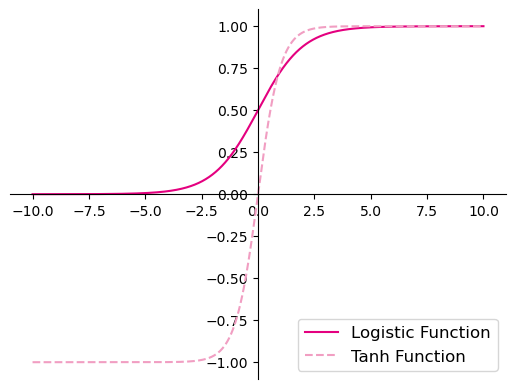

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

# Logistic函数 \sigma(x)
def logistic(z):
    return 1.0 / (1.0 + paddle.exp(-z))

# Tanh函数
def tanh(z):
    return (paddle.exp(z) - paddle.exp(-z)) / (paddle.exp(z) + paddle.exp(-z))

# 在[-10, 10]的范围内生成1w个输入值, 用于绘制函数曲线
z = paddle.linspace(-10, 10, 1e4)

plt.figure()
plt.plot(z.tolist(), logistic(z).tolist(), color="#e4007f", label="Logistic Function")
plt.plot(z.tolist(), tanh(z).tolist(), color="#f19ec2", linestyle="--",
        label="Tanh Function")

ax = plt.gca()  # 获取轴, 默认有4个
# 隐藏两个轴, 通过把颜色设置成none
ax.spines["top"].set_color("none")
ax.spines["right"].set_color("none")
# 调整坐标轴位置
ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))
plt.legend(loc="lower right", fontsize="large")

plt.savefig("fw-logistic-tanh.pdf")
plt.show()

#### 4.1.2.2 ReLU型函数

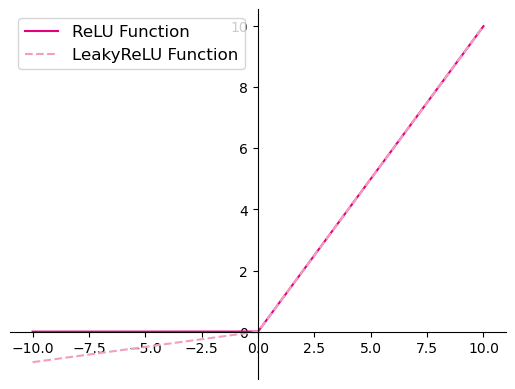

In [4]:
# ReLU
def relu(z):  # max(0, x)
    return paddle.maximum(z, paddle.to_tensor(0.))

# 带泄露的ReLU
def leaky_relu(z, negative_slope=0.1):  # max(0, x) + \gamma min(0, x).
    # 当前版本的paddle暂不支持直接将bool类型转成int类型，因此调用了paddle的cast函数来进行显示转换
    a1 = (paddle.cast((z > 0), dtype="float32") * z)
    a2 = (paddle.cast((z <= 0), dtype="float32") * (negative_slope * z))
    return a1 + a2

# 在[-10, 10]的范围内生成一系列的输入值，用于绘制relu、leaky_relu的函数曲线
z = paddle.linspace(-10, 10, 1e4)

plt.figure()
plt.plot(z.tolist(), relu(z).tolist(), color="#e4007f", label="ReLU Function")
plt.plot(z.tolist(), leaky_relu(z).tolist(), color="#f19ec2", linestyle="--",
        label="LeakyReLU Function")

ax = plt.gca()
ax.spines["top"].set_color("none")
ax.spines["right"].set_color("none")
ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))
plt.legend(loc="upper left", fontsize="large")
plt.savefig("fw-relu-leakyreli.pdf")
plt.show()

请动手实现《神经网络与深度学习》4.1节中提到的其他激活函数，如：Hard-Logistic、Hard-Tanh、ELU、Softplus、Swish等。

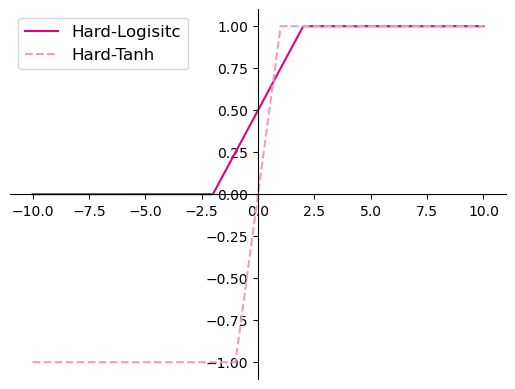

In [15]:
# Hard-Logistic
def g_l(x):
    return 0.25 * x + 0.5


def hard_logistic(x):  # max(min(0.25x+0.5, 1), 0)
    g = g_l(x)
    a1 = (paddle.cast((g >= 1), dtype="float32") * 1.0)
    a2 = (paddle.cast((0 < g) & (g < 1), dtype="float32") * g)
    a3 = (paddle.cast((g <= 0), dtype="float32") * 0.0)
    return a1 + a2 + a3
    

def g_t(x):
    return x


def hard_tanh(x):  # max(min(x, 1), -1)
    a1 = paddle.minimum(x, paddle.to_tensor(1.))
    return paddle.maximum(a1, paddle.to_tensor(-1.))
    

z = paddle.linspace(-10, 10, 10000)

plt.figure()
plt.plot(z.tolist(), hard_logistic(z).tolist(), color="#e4007f", label="Hard-Logisitc")
plt.plot(z.tolist(), hard_tanh(z).tolist(), color="#f19ec2", linestyle="--",
        label="Hard-Tanh")

ax = plt.gca()
ax.spines["top"].set_color("none")
ax.spines["right"].set_color("none")
ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))
plt.legend(loc="upper left", fontsize="large")
plt.savefig("fw-hardlogistic-hardtanh.pdf")
plt.show()

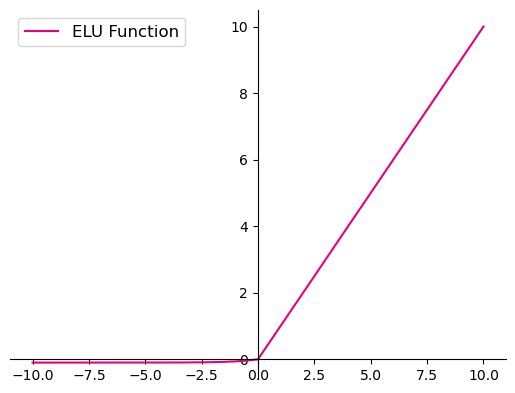

In [18]:
# ELU
def elu(x, negative_slope=0.1):
    a1 = (paddle.cast((x > 0), dtype="float32") * x)
    a2 = (paddle.cast((x <= 0), dtype="float32") * (negative_slope * (paddle.exp(x) - 1)))
    return a1 + a2


z = paddle.linspace(-10, 10, 10000)

plt.figure()
plt.plot(z.tolist(), elu(z).tolist(), color="#e4007f", label="ELU Function")

ax = plt.gca()
ax.spines["top"].set_color("none")
ax.spines["right"].set_color("none")
ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))
plt.legend(loc="upper left", fontsize="large")
plt.savefig("fw-elu.pdf")

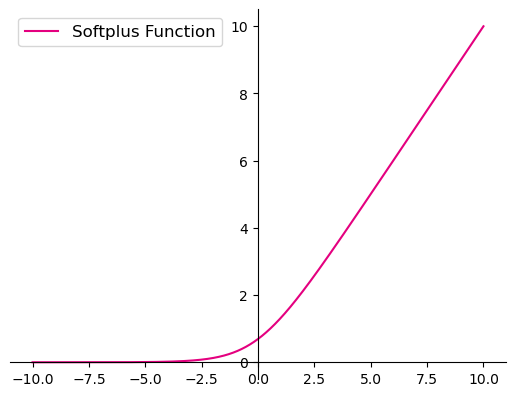

In [19]:
# Softplus
def softplus(x):
    return paddle.log(1 + paddle.exp(x))


z = paddle.linspace(-10, 10, 10000)

plt.figure()
plt.plot(z.tolist(), softplus(z).tolist(), color="#e4007f", label="Softplus Function")

ax = plt.gca()
ax.spines["top"].set_color("none")
ax.spines["right"].set_color("none")
ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))
plt.legend(loc="upper left", fontsize="large")
plt.savefig("fw-softplus.pdf")

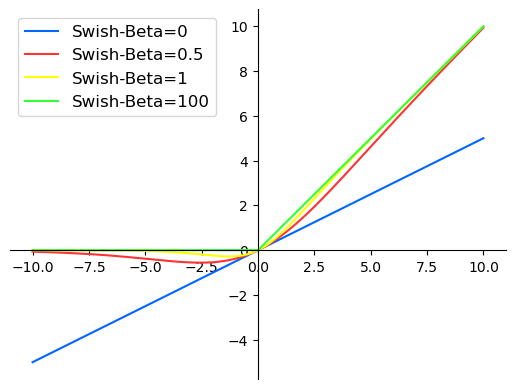

In [20]:
# Swish
def swish(x, beta=1):
    return x * logistic(x * beta)


z = paddle.linspace(-10, 10, 10000)
plt.figure()
plt.plot(z.tolist(), swish(z, beta=0).tolist(), color="#0066ff", label="Swish-Beta=0")
plt.plot(z.tolist(), swish(z, beta=0.5).tolist(), color="#ff3333", label="Swish-Beta=0.5")
plt.plot(z.tolist(), swish(z, beta=1).tolist(), color="#ffff00", label="Swish-Beta=1")
plt.plot(z.tolist(), swish(z, beta=100).tolist(), color="#33ff33", label="Swish-Beta=100")

ax = plt.gca()
ax.spines["top"].set_color("none")
ax.spines["right"].set_color("none")
ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))
plt.legend(loc="upper left", fontsize="large")
plt.savefig("fw-Swish.pdf")

## 4.2 基于前馈神经网络的二分类任务